In [1]:
# ==========================================
# CODE 5 / NOTEBOOK 5
# SEARCH AND RESCUE (SAR) RESPONSE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# -----------------------------
# 1. LOAD CLEANED DATA
# -----------------------------
df = pd.read_csv("occurrences_cleaned.csv")
df.head()

,occurrence_id,local_date_main_event,date_main_event_unconfirmed,year_reported,occurrence_severity,main_event_l1,main_event_l2,main_event_l3,not_vessel_operations,short_description,description,national_keywords,emcip_keywords,sar_intervention,state_reporting,occurrence_location,coastal_state_affected,national_location_l1,national_location_l2,latitude,longitude,lat_long_unknown,port_of_accident_l1,port_of_accident_l2,natural_light,sea_state,visibility,weather,wind_force,publication_date,publication_no,publication_type,published_report_website_link,occurrence_record_modified_on,last_updated_at,occurrences_reported_from,occurrences_reported_to
0,1f59ae23-e48f-ec11-b400-000d3a874c7b,2022-02-01,No,2022,Marine Incident,Contact,Shore Object,NaN,False,A ro-ro cargo vessel made contact with quay side,A ro-ro cargo vessel was manoeuvring to line up to enter a lock when the vessel made contact with the eastern approach causing damage to at least two fenders. A tug was assisting the vessel.,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,England,53.6383,-0.199300,NaN,UNITED KINGDOM,Immingham,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
1,c51366b7-39cd-ec11-a7b6-0022481a81f8,2022-04-01,No,2022,Marine Incident,Damage / Loss Of Equipment,NaN,NaN,False,A service vessel drifted from a quayside resulting in a gangway falling into the water,A service vessel entered a port through lock gates and came alongside with a tie up of a breast line forward and aft. A gangway was then deployed. The vessel started to drift astern with the bow c...,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,Scotland,55.9869,-3.176900,NaN,UNITED KINGDOM,Leith,Daylight,1 - Calm rippled - (0 - 0.1 m),Good - 5.0 <= Vis < 25.0 nm,Clear,4 - Moderate Breeze - knot (11-16) m/s (6-8),NaN,NaN,NaN,NaN,2025-03-28,2026-05-15,2020-01-01,2025-12-31
2,883d7a39-90e1-ec11-bb3d-000d3a0cda10,2022-05-01,No,2022,Marine Incident,Accident to person(s),NaN,NaN,False,A inland passenger vessel passenger fell down stairs resulting in a head laceration,An inland waterways passenger vessel passenger fell whilst onboard resulting in a head injury. The passenger refused assistance from an ambulance and made their own way to hospital.,NaN,NaN,No,UK,Inland waters -> River,UNITED KINGDOM,United Kingdom,England,51.5074,-0.082500,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-03-13,2026-05-15,2020-01-01,2025-12-31
3,68afeb11-12ee-ec11-bb3c-000d3a0d2897,2022-06-01,No,2022,Marine Incident,Loss Of Control,Loss Of Propulsion Power,NaN,False,Fishing vessel's gearbox failed resulting in a tow.,Fishing vessel's gearbox failed resulting in a tow from another fishing vessel. The casualty vessel was not in danger at any point.,NaN,NaN,No,UK,Open sea -> Within EEZ,None/Register withdrawn,NaN,NaN,50.0644,-3.417183,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
4,d40d9f19-bd0c-ed11-b83d-0022481b1890,2022-07-01,No,2022,Less Serious,Accident to person(s),NaN,NaN,False,A sailing yacht crew member sustained a partial amputation to two fingers,"A sailing yacht was seeking shelter as the wind was due, the crew set about stowing the sails. The furling gear had loosened, a crew member went forward to furl the genoa. As they rotated the furl...",NaN,NaN,Yes,UK,Coastal waters <= 12 nm,UNITED KINGDOM,United Kingdom,Scotland,56.2847,-6.243700,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-02-23,2026-05-15,2020-01-01,2025-12-31


In [3]:
# -----------------------------
# 2. BASIC PREPARATION
# -----------------------------
df.columns = df.columns.str.strip().str.lower()

df["local_date_main_event"] = pd.to_datetime(df["local_date_main_event"], errors="coerce")
df["event_year"] = df["local_date_main_event"].dt.year

text_cols = [
    "sar_intervention",
    "occurrence_severity",
    "main_event_l1",
    "main_event_l2",
    "occurrence_location",
    "national_location_l1",
    "national_location_l2",
    "short_description",
    "description"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

print("Dataset shape:", df.shape)

Dataset shape: (8599, 38)


In [19]:
# -----------------------------
# 3. CLEAN SAR CORE FIELDS
# -----------------------------
def clean_category(series):
    s = series.astype("string").str.strip()

    s = s.replace({
        "<NA>": pd.NA,
        "NA": pd.NA,
        "N/A": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "": pd.NA
    })

    return s.fillna("Unknown")


df["sarplot"] = clean_category(df["sar_intervention"]).replace({
    "YES": "Yes",
    "Yes": "Yes",
    "yes": "Yes",
    "NO": "No",
    "No": "No",
    "no": "No",
    "UNKNOWN": "Unknown",
    "unknown": "Unknown"
})

df["severityplot"] = clean_category(df["occurrence_severity"])
df["eventl1plot"] = clean_category(df["main_event_l1"])
df["eventl2plot"] = clean_category(df["main_event_l2"])
df["locationplot"] = clean_category(df["occurrence_location"])
df["countryplot"] = clean_category(df["national_location_l1"])
df["regionplot"] = clean_category(df["national_location_l2"])

print(df["sarplot"].value_counts(dropna=False))

sarplot
No         6833
Yes        1747
Unknown      19
Name: count, dtype: Int64


In [20]:
# -----------------------------
# 3B. VALIDATE KEY CATEGORIES
# -----------------------------
key_cols = [
    "sar_intervention",
    "occurrence_severity",
    "main_event_l1",
    "main_event_l2",
    "occurrence_location",
    "national_location_l1",
    "national_location_l2"
]

for col in key_cols:
    print(f"\n===== {col.upper()} =====")
    print("Missing:", df[col].isna().sum())
    print(df[col].astype("string").str.strip().value_counts(dropna=False).head(15))


===== SAR_INTERVENTION =====
Missing: 0
sar_intervention
No         6833
Yes        1747
Unknown      19
Name: count, dtype: Int64

===== OCCURRENCE_SEVERITY =====
Missing: 0
occurrence_severity
Marine Incident    4759
Less Serious       3116
Serious             426
Very Serious        298
Name: count, dtype: Int64

===== MAIN_EVENT_L1 =====
Missing: 2
main_event_l1
Accident to person(s)         2381
Damage / Loss Of Equipment    1910
Loss Of Control               1342
Grounding / Stranding          866
Contact                        640
Collision                      526
Fire / Explosion               462
Flooding / Foundering          296
Capsizing / Listing            157
Hull Failure                    10
Heavy Weather Damage             3
Non-accidental Event             3
<NA>                             2
Missing                          1
Name: count, dtype: Int64

===== MAIN_EVENT_L2 =====
Missing: 4351
main_event_l2
<NA>                           4351
Loss Of Propulsion Powe

In [21]:
# -----------------------------
# 4. SAR DISTRIBUTION
# -----------------------------
sar_order = ["No", "Yes", "Unknown"]

sarcounts = (
    df["sarplot"]
    .value_counts()
    .reindex(sar_order, fill_value=0)
    .reset_index()
)

sarcounts.columns = ["sar_intervention", "count"]
sarcounts["pct"] = (sarcounts["count"] / len(df)) * 100

print("\n===== SAR INTERVENTION DISTRIBUTION =====")
print(sarcounts)


===== SAR INTERVENTION DISTRIBUTION =====
  sar_intervention  count        pct
0               No   6833  79.462728
1              Yes   1747  20.316316
2          Unknown     19   0.220956


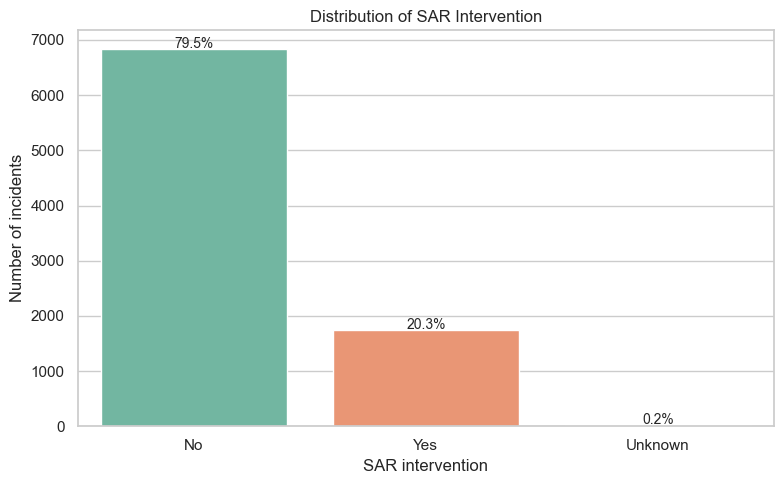

In [22]:
# -----------------------------
# 5. PLOT SAR DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sarcounts,
    x="sar_intervention",
    y="count",
    hue="sar_intervention",
    palette="Set2",
    legend=False
)

for i, row in sarcounts.iterrows():
    plt.text(i, row["count"] + 20, f'{row["pct"]:.1f}%', ha="center", fontsize=10)

plt.title("Distribution of SAR Intervention")
plt.xlabel("SAR intervention")
plt.ylabel("Number of incidents")
plt.tight_layout()
plt.show()

In [7]:
# -----------------------------
# 6. SAR BY SEVERITY
# -----------------------------
sar_by_severity = pd.crosstab(
    df["severity_plot"],
    df["sar_plot"]
)

sar_by_severity_pct = pd.crosstab(
    df["severity_plot"],
    df["sar_plot"],
    normalize="index"
) * 100

print("\n===== SAR BY SEVERITY (COUNTS) =====")
print(sar_by_severity)

print("\n===== SAR BY SEVERITY (ROW %) =====")
print(sar_by_severity_pct.round(2))


===== SAR BY SEVERITY (COUNTS) =====
sar_plot           No  Unknown  Yes
severity_plot                      
Less Serious     2501        6  609
Marine Incident  4021        7  731
Serious           241        2  183
Very Serious       70        4  224

===== SAR BY SEVERITY (ROW %) =====
sar_plot            No  Unknown    Yes
severity_plot                         
Less Serious     80.26     0.19  19.54
Marine Incident  84.49     0.15  15.36
Serious          56.57     0.47  42.96
Very Serious     23.49     1.34  75.17


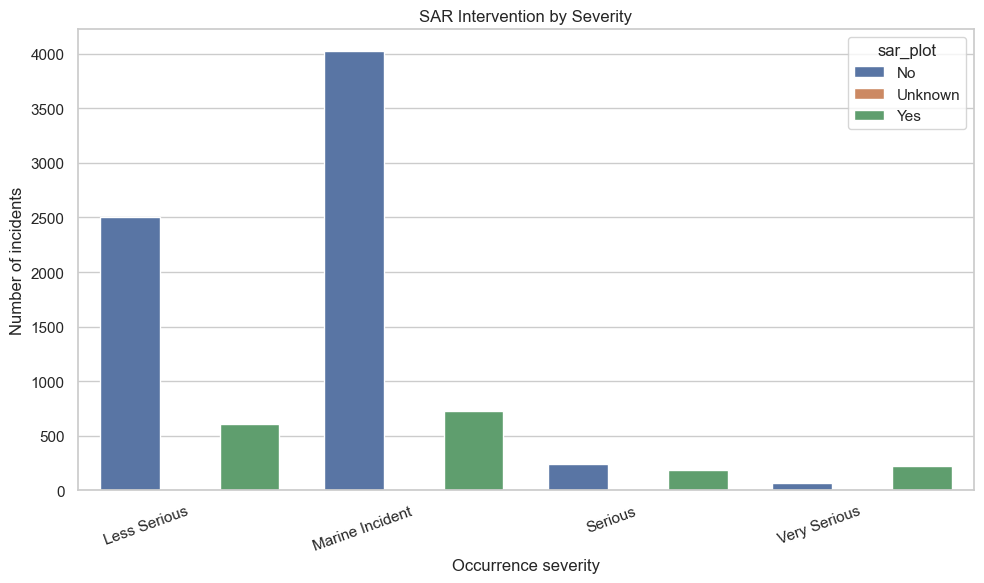

In [8]:
# -----------------------------
# 7. PLOT: SAR BY SEVERITY
# -----------------------------
sar_severity_plot = (
    df.groupby(["severity_plot", "sar_plot"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sar_severity_plot,
    x="severity_plot",
    y="count",
    hue="sar_plot"
)
plt.title("SAR Intervention by Severity")
plt.xlabel("Occurrence severity")
plt.ylabel("Number of incidents")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# -----------------------------
# 8. SAR RATE BY SEVERITY
# -----------------------------
sar_yes_rate_severity = (
    df.assign(sar_yes=np.where(df["sar_plot"] == "Yes", 1, 0))
      .groupby("severity_plot")["sar_yes"]
      .mean()
      .reset_index()
)

sar_yes_rate_severity["sar_yes_pct"] = sar_yes_rate_severity["sar_yes"] * 100
sar_yes_rate_severity = sar_yes_rate_severity.sort_values("sar_yes_pct", ascending=False)

print("\n===== SAR YES RATE BY SEVERITY =====")
print(sar_yes_rate_severity[["severity_plot", "sar_yes_pct"]].round(2))


===== SAR YES RATE BY SEVERITY =====
     severity_plot  sar_yes_pct
3     Very Serious        75.17
2          Serious        42.96
0     Less Serious        19.54
1  Marine Incident        15.36


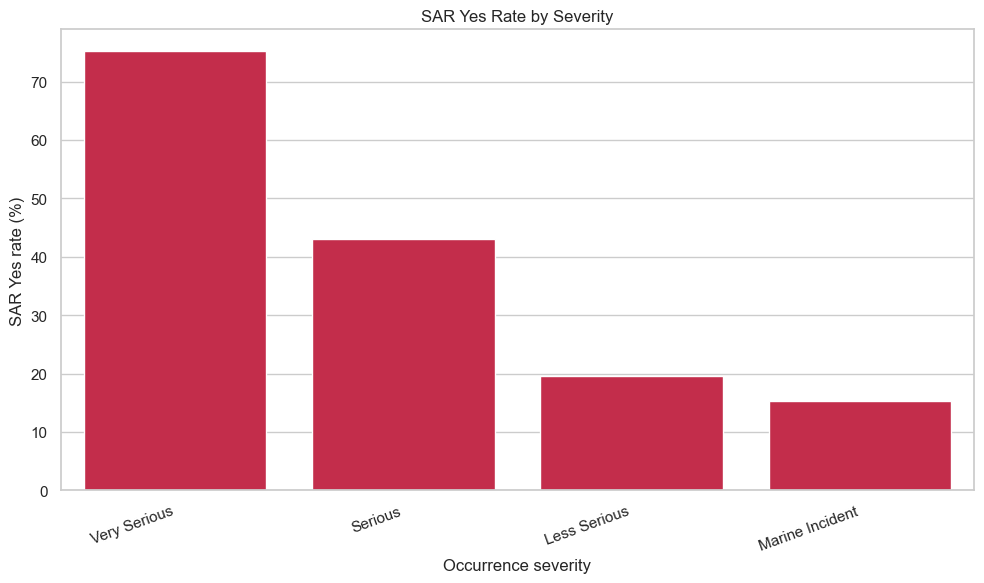

In [10]:
# -----------------------------
# 9. PLOT: SAR YES RATE BY SEVERITY
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sar_yes_rate_severity,
    x="severity_plot",
    y="sar_yes_pct",
    color="crimson"
)
plt.title("SAR Yes Rate by Severity")
plt.xlabel("Occurrence severity")
plt.ylabel("SAR Yes rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [23]:
# -----------------------------
# 10. SAR YES RATE BY MAIN EVENT L1
# -----------------------------
saryesrateevent = (
    df.assign(sar_yes=np.where(df["sarplot"] == "Yes", 1, 0))
      .groupby("eventl1plot")
      .agg(
          incidents=("eventl1plot", "size"),
          sar_yes_rate=("sar_yes", "mean")
      )
      .reset_index()
)

saryesrateevent["sar_yes_pct"] = saryesrateevent["sar_yes_rate"] * 100

# raise threshold so tiny groups do not dominate ranking
saryesrateevent = saryesrateevent[saryesrateevent["incidents"] >= 20]

saryesrateevent = saryesrateevent.sort_values(
    ["sar_yes_pct", "incidents"],
    ascending=[False, False]
)

print("\n===== SAR YES RATE BY MAIN EVENT L1 =====")
print(
    saryesrateevent[["eventl1plot", "incidents", "sar_yes_pct"]]
    .head(15)
    .round({"sar_yes_pct": 2})
)


===== SAR YES RATE BY MAIN EVENT L1 =====
                   eventl1plot  incidents  sar_yes_pct
6        Flooding / Foundering        296        63.51
1          Capsizing / Listing        157        55.41
10             Loss Of Control       1342        40.54
7        Grounding / Stranding        866        33.60
5             Fire / Explosion        462        28.35
0        Accident to person(s)       2381        15.46
2                    Collision        526         7.41
3                      Contact        640         5.78
4   Damage / Loss Of Equipment       1910         2.57


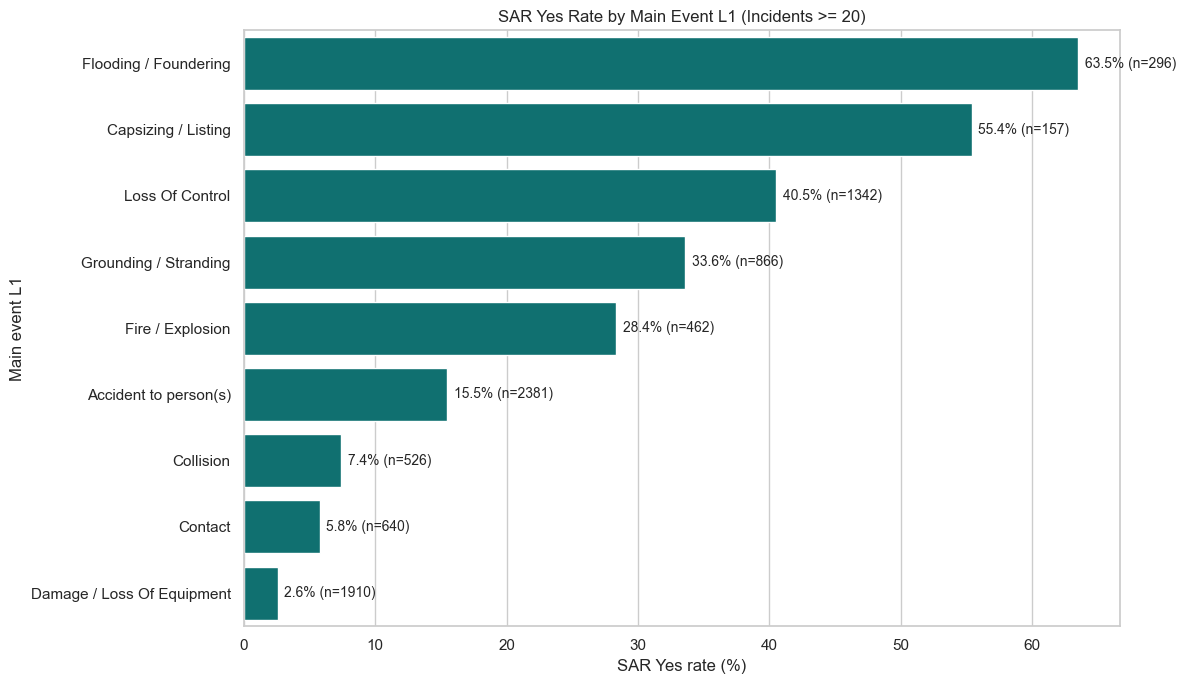

In [24]:
# -----------------------------
# 11. PLOT SAR YES RATE BY MAIN EVENT L1
# -----------------------------
plot_l1 = saryesrateevent.head(12).copy()

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_l1,
    y="eventl1plot",
    x="sar_yes_pct",
    color="teal"
)

for i, row in plot_l1.reset_index(drop=True).iterrows():
    ax.text(
        row["sar_yes_pct"] + 0.5,
        i,
        f'{row["sar_yes_pct"]:.1f}% (n={row["incidents"]})',
        va="center",
        fontsize=10
    )

plt.title("SAR Yes Rate by Main Event L1 (Incidents >= 20)")
plt.xlabel("SAR Yes rate (%)")
plt.ylabel("Main event L1")
plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# 12. SAR BY OCCURRENCE LOCATION
# -----------------------------
sar_yes_rate_location = (
    df.assign(sar_yes=np.where(df["sar_plot"] == "Yes", 1, 0))
      .groupby("location_plot")
      .agg(
          incidents=("location_plot", "size"),
          sar_yes_rate=("sar_yes", "mean")
      )
      .reset_index()
)

sar_yes_rate_location["sar_yes_pct"] = sar_yes_rate_location["sar_yes_rate"] * 100
sar_yes_rate_location = sar_yes_rate_location.sort_values("sar_yes_pct", ascending=False)

print("\n===== SAR YES RATE BY OCCURRENCE LOCATION =====")
print(sar_yes_rate_location[["location_plot", "incidents", "sar_yes_pct"]].round(2))


===== SAR YES RATE BY OCCURRENCE LOCATION =====
                             location_plot  incidents  sar_yes_pct
3                    Inland waters -> Lake         65        44.62
0                  Coastal waters <= 12 nm       3807        31.63
7        Internal waters -> Channel, river        155        29.03
6   Internal waters -> Archipelago fairway          8        25.00
4                   Inland waters -> River        381        23.10
1                            Inland waters         31        22.58
10                  Open sea -> Within EEZ        578        21.80
2                 Inland waters -> Channel         32        15.62
8             Internal waters -> Port area       3356         6.82
9                  Open sea -> Outside EEZ        184         6.52
5                          Internal waters          1         0.00
11                                 Unknown          1         0.00


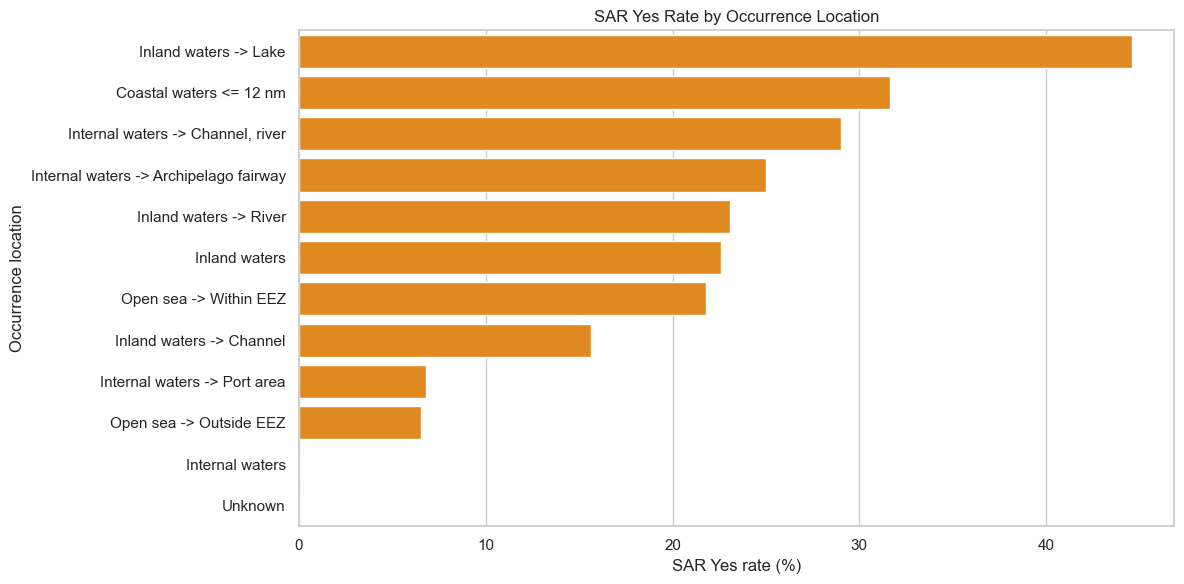

In [14]:
# -----------------------------
# 13. PLOT: SAR YES RATE BY LOCATION
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=sar_yes_rate_location,
    y="location_plot",
    x="sar_yes_pct",
    color="darkorange"
)
plt.title("SAR Yes Rate by Occurrence Location")
plt.xlabel("SAR Yes rate (%)")
plt.ylabel("Occurrence location")
plt.tight_layout()
plt.show()

In [30]:
# -----------------------------
# 14. YEARLY TREND IN SAR INTERVENTION
# -----------------------------
sar_year = (
    df.groupby(["event_year", "sar_plot"])
      .size()
      .reset_index(name="count")
      .sort_values(["event_year", "sar_plot"])
)

print("\n===== YEARLY SAR TREND =====")
print(sar_year.head(20))


===== YEARLY SAR TREND =====
    event_year sar_plot  count
0         2018       No      3
1         2019       No     16
2         2019      Yes      2
3         2020       No    887
4         2020  Unknown      5
5         2020      Yes    323
6         2021       No   1075
7         2021  Unknown      4
8         2021      Yes    420
9         2022       No   1003
10        2022  Unknown      4
11        2022      Yes    249
12        2023       No   1408
13        2023  Unknown      2
14        2023      Yes    182
15        2024       No   1269
16        2024  Unknown      1
17        2024      Yes    244
18        2025       No   1172
19        2025  Unknown      3


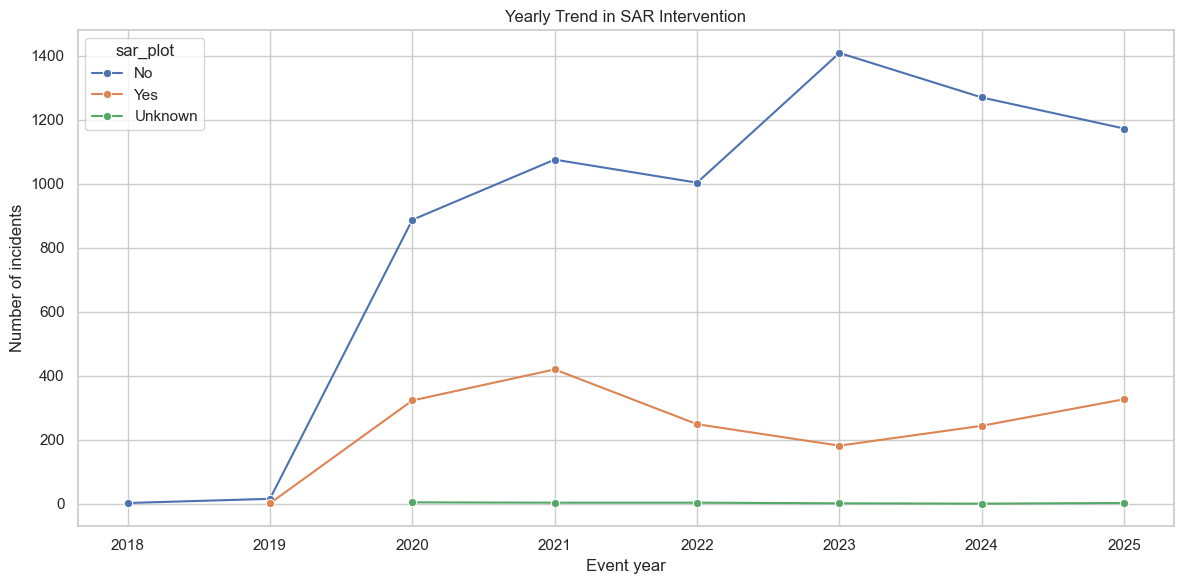

In [29]:
# -----------------------------
# 15. PLOT: YEARLY SAR TREND
# -----------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=sar_year,
    x="event_year",
    y="count",
    hue="sar_plot",
    marker="o"
)
plt.title("Yearly Trend in SAR Intervention")
plt.xlabel("Event year")
plt.ylabel("Number of incidents")
plt.tight_layout()
plt.show()

In [17]:
# -----------------------------
# 16. SAR CASE EXAMPLES
# -----------------------------
sar_examples = df[df["sar_plot"] == "Yes"][
    [
        "local_date_main_event",
        "severity_plot",
        "event_l1_plot",
        "location_plot",
        "region_plot",
        "short_description"
    ]
].sort_values("local_date_main_event")

print("\n===== SAR CASE EXAMPLES =====")
print(sar_examples.head(15))


===== SAR CASE EXAMPLES =====
     local_date_main_event    severity_plot          event_l1_plot  \
446             2019-07-01     Less Serious  Grounding / Stranding   
147             2019-08-01     Less Serious        Loss Of Control   
7616            2020-01-01  Marine Incident        Loss Of Control   
8267            2020-01-01     Less Serious        Loss Of Control   
7897            2020-01-01     Less Serious  Accident to person(s)   
8395            2020-01-01  Marine Incident        Loss Of Control   
8425            2020-01-01     Less Serious        Loss Of Control   
8028            2020-01-01     Less Serious        Loss Of Control   
7432            2020-02-01     Less Serious        Loss Of Control   
8416            2020-02-01  Marine Incident       Fire / Explosion   
7584            2020-02-01     Less Serious        Loss Of Control   
8480            2020-02-01          Serious   Heavy Weather Damage   
7627            2020-02-01          Serious  Grounding / St

In [18]:
# -----------------------------
# 17. TOP EVENT L2 WITH SAR = YES
# -----------------------------
sar_yes_event_l2 = (
    df[df["sar_plot"] == "Yes"]["event_l2_plot"]
      .value_counts()
      .reset_index()
)
sar_yes_event_l2.columns = ["event_l2", "count"]

print("\n===== TOP EVENT L2 FOR SAR = YES =====")
print(sar_yes_event_l2.head(15))


===== TOP EVENT L2 FOR SAR = YES =====
                       event_l2  count
0      Loss Of Propulsion Power    460
1                       Unknown    443
2                         Power    202
3                      Flooding    145
4                          Fire    117
5                     Capsizing     87
6                         Drift     78
7   Loss Of Directional Control     53
8                    Foundering     43
9      Loss Of Electrical Power     30
10              With Other Ship     26
11              Floating Object     24
12                 Shore Object     13
13                    Explosion     13
14            Ship Not Underway     11
